In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [2]:
data = pd.read_csv("./Data/data_collected.csv")

In [3]:
data.head()

,DateTime,currency,event,actual,previous,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after
0,2024-01-02 14:45:00,USD,Final Manufacturing PMI,47.9,48.2,141.939,141.947,141.990,143.252,144.581
1,2024-01-02 15:00:00,USD,Construction Spending m/m,0.4%,1.2%,141.982,141.952,141.958,143.258,144.567
2,2024-01-03 15:00:00,USD,ISM Manufacturing PMI,47.4,46.7,143.300,143.258,143.167,144.567,144.668
3,2024-01-04 00:30:00,JPY,Final Manufacturing PMI,47.9,47.7,143.617,143.640,143.824,144.674,144.424
4,2024-01-04 12:30:00,USD,Challenger Job Cuts y/y,-20.2%,-40.8%,144.563,144.615,144.647,144.770,143.921


In [4]:
# creating a feature data

feature_data = data.copy()

In [5]:
feature_data["DateTime"] = pd.to_datetime(feature_data["DateTime"])

In [6]:
feature_data.dtypes

DateTime             datetime64[ns]
currency                     object
event                        object
actual                       object
previous                     object
Close_5min_before           float64
Close_at_release            float64
Close_5min_after            float64
Close_24h_after             float64
Close_48h_after             float64
dtype: object

In [7]:
# changes in price in 5mins


feature_data["price_change_5min"] = (
    data["Close_5min_after"] -
    data["Close_at_release"]
)

In [8]:
# 24hr price change

feature_data["Price_Change_24h"] = (
    data["Close_24h_after"] -
    data["Close_at_release"]
)

In [9]:
feature_data.head(2)

,DateTime,currency,event,actual,previous,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after,price_change_5min,Price_Change_24h
0,2024-01-02 14:45:00,USD,Final Manufacturing PMI,47.9,48.2,141.939,141.947,141.990,143.252,144.581,0.043,1.305
1,2024-01-02 15:00:00,USD,Construction Spending m/m,0.4%,1.2%,141.982,141.952,141.958,143.258,144.567,0.006,1.306


In [10]:
## 48hrs price change

feature_data["Price_Change_48h"] = (
    data["Close_48h_after"] -
    data["Close_at_release"]
)

In [11]:
## creating a directional label 5min

feature_data["Direction_5min"] = np.where(

    feature_data["price_change_5min"] > 0,

    "Bullish",

    "Bearish"

)

In [12]:
## direction 24hrs

feature_data["Direction_24h"] = np.where(

    feature_data["Price_Change_24h"] > 0,

    "Bullish",

    "Bearish"

)

In [13]:
## directional change 48hrs

feature_data["Direction_48h"] = np.where(

    feature_data["Price_Change_48h"] > 0,

    "Bullish",

    "Bearish"

)

In [14]:
feature_data.head(2)

,DateTime,currency,event,actual,previous,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after,price_change_5min,Price_Change_24h,Price_Change_48h,Direction_5min,Direction_24h,Direction_48h
0,2024-01-02 14:45:00,USD,Final Manufacturing PMI,47.9,48.2,141.939,141.947,141.990,143.252,144.581,0.043,1.305,2.634,Bullish,Bullish,Bullish
1,2024-01-02 15:00:00,USD,Construction Spending m/m,0.4%,1.2%,141.982,141.952,141.958,143.258,144.567,0.006,1.306,2.615,Bullish,Bullish,Bullish


In [15]:
feature_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   DateTime           762 non-null    datetime64[ns]
 1   currency           762 non-null    object        
 2   event              762 non-null    object        
 3   actual             762 non-null    object        
 4   previous           762 non-null    object        
 5   Close_5min_before  762 non-null    float64       
 6   Close_at_release   762 non-null    float64       
 7   Close_5min_after   762 non-null    float64       
 8   Close_24h_after    762 non-null    float64       
 9   Close_48h_after    762 non-null    float64       
 10  price_change_5min  762 non-null    float64       
 11  Price_Change_24h   762 non-null    float64       
 12  Price_Change_48h   762 non-null    float64       
 13  Direction_5min     762 non-null    object        
 14  Direction_

In [16]:
feature_data.isna().sum()

DateTime             0
currency             0
event                0
actual               0
previous             0
Close_5min_before    0
Close_at_release     0
Close_5min_after     0
Close_24h_after      0
Close_48h_after      0
price_change_5min    0
Price_Change_24h     0
Price_Change_48h     0
Direction_5min       0
Direction_24h        0
Direction_48h        0
dtype: int64

In [17]:
## converting actual and previous values to numbers

def convert_to_numeric(value):

    if pd.isna(value):
        return np.nan

    value = str(value).replace(",", "").replace("%", "").strip()

    multiplier = 1

    if value.endswith("K"):
        multiplier = 1_000
        value = value[:-1]

    elif value.endswith("M"):
        multiplier = 1_000_000
        value = value[:-1]

    elif value.endswith("B"):
        multiplier = 1_000_000_000
        value = value[:-1]

    try:
        return float(value) * multiplier

    except:
        return np.nan

In [18]:
# converting actuel

feature_data["Actual_Num"] = feature_data["actual"].apply(convert_to_numeric)

In [19]:
## convert previos

feature_data["Previous_Num"] = feature_data["previous"].apply(convert_to_numeric)

In [20]:
feature_data[[
    "actual",
    "Actual_Num",
    "previous",
    "Previous_Num"
]].head()

,actual,Actual_Num,previous,Previous_Num
0,47.9,47.9,48.2,48.2
1,0.4%,0.4,1.2%,1.2
2,47.4,47.4,46.7,46.7
3,47.9,47.9,47.7,47.7
4,-20.2%,-20.2,-40.8%,-40.8


In [21]:
feature_data.dtypes

DateTime             datetime64[ns]
currency                     object
event                        object
actual                       object
previous                     object
Close_5min_before           float64
Close_at_release            float64
Close_5min_after            float64
Close_24h_after             float64
Close_48h_after             float64
price_change_5min           float64
Price_Change_24h            float64
Price_Change_48h            float64
Direction_5min               object
Direction_24h                object
Direction_48h                object
Actual_Num                  float64
Previous_Num                float64
dtype: object

In [22]:
##creating the change in newsrelease value features

feature_data["news_change"] = (

    feature_data["Actual_Num"]

    -

    feature_data["Previous_Num"]

)


In [23]:
feature_data[[
    "Actual_Num",
    "Previous_Num",
    "news_change"
]].head()

,Actual_Num,Previous_Num,news_change
0,47.9,48.2,-0.3
1,0.4,1.2,-0.8
2,47.4,46.7,0.7
3,47.9,47.7,0.2
4,-20.2,-40.8,20.6


In [24]:
## percentage news change

feature_data["news_change_Percentage"] = (

    feature_data["news_change"]

    /

    feature_data["Previous_Num"].abs()

) * 100

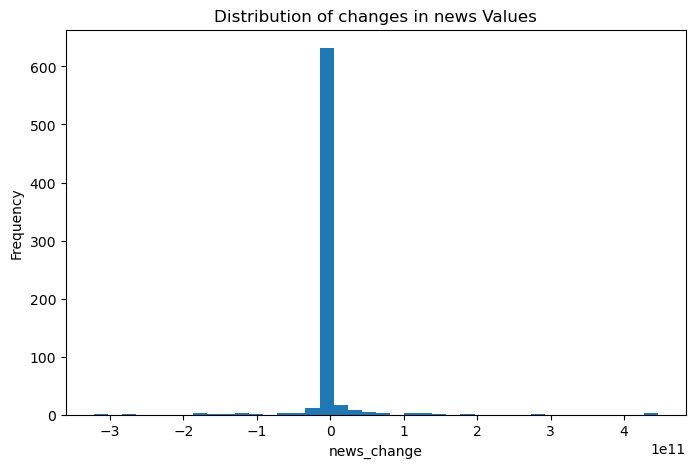

In [25]:
plt.figure(figsize=(8,5))

plt.hist(feature_data["news_change"], bins=40)

plt.title("Distribution of changes in news Values")

plt.xlabel("news_change")

plt.ylabel("Frequency")

plt.show()

In [26]:
feature_data.nlargest(
    10,
    "news_change"
)[[
    "DateTime",
    "currency",
    "event",
    "Actual_Num",
    "Previous_Num",
    "news_change"
]]

,DateTime,currency,event,Actual_Num,Previous_Num,news_change
273,2024-05-10 18:00:00,USD,Federal Budget Balance,2.095000e+11,-2.365000e+11,4.460000e+11
608,2024-10-18 20:00:00,USD,Federal Budget Balance,6.430000e+10,-3.801000e+11,4.444000e+11
405,2024-07-11 18:00:00,USD,Federal Budget Balance,-6.600000e+10,-3.471000e+11,2.811000e+11
25,2024-01-11 19:00:00,USD,Federal Budget Balance,-1.294000e+11,-3.140000e+11,1.846000e+11
477,2024-08-15 20:00:00,USD,TIC Long-Term Purchases,9.610000e+10,-5.410000e+10,1.502000e+11
66,2024-02-01 15:30:00,USD,Natural Gas Storage,-1.970000e+11,-3.260000e+11,1.290000e+11
42,2024-01-19 21:00:00,USD,TIC Long-Term Purchases,1.261000e+11,3.400000e+09,1.227000e+11
82,2024-02-08 15:30:00,USD,Natural Gas Storage,-7.500000e+10,-1.970000e+11,1.220000e+11
86,2024-02-12 19:00:00,USD,Federal Budget Balance,-2.190000e+10,-1.294000e+11,1.075000e+11
673,2024-11-18 21:00:00,USD,TIC Long-Term Purchases,2.161000e+11,1.088000e+11,1.073000e+11


In [27]:
feature_data.head(2)

,DateTime,currency,event,actual,previous,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after,price_change_5min,Price_Change_24h,Price_Change_48h,Direction_5min,Direction_24h,Direction_48h,Actual_Num,Previous_Num,news_change,news_change_Percentage
0,2024-01-02 14:45:00,USD,Final Manufacturing PMI,47.9,48.2,141.939,141.947,141.990,143.252,144.581,0.043,1.305,2.634,Bullish,Bullish,Bullish,47.9,48.2,-0.3,-0.622407
1,2024-01-02 15:00:00,USD,Construction Spending m/m,0.4%,1.2%,141.982,141.952,141.958,143.258,144.567,0.006,1.306,2.615,Bullish,Bullish,Bullish,0.4,1.2,-0.8,-66.666667


In [28]:
### replacing infinite values

feature_data.replace(

    [np.inf, -np.inf],

    np.nan,

    inplace=True

)

In [29]:
## encoding usd and jpy currency

feature_data["Currency_Code"] = (

    feature_data["currency"]

    .map({

        "USD":1,

        "JPY":0

    })

)

In [30]:
feature_data[[
    "currency",
    "Currency_Code"
]].head()

,currency,Currency_Code
0,USD,1
1,USD,1
2,USD,1
3,JPY,0
4,USD,1


In [31]:
## time feature in hr

feature_data["Time"] = feature_data["DateTime"].dt.strftime("%H:%M")

In [32]:
## day

feature_data["Day"] = feature_data["DateTime"].dt.dayofweek

In [33]:
## month

feature_data["Month"] = feature_data["DateTime"].dt.month

In [34]:
## year

feature_data["Year"] = feature_data["DateTime"].dt.year

## Price difference features



In [35]:
#before and release

feature_data["Move_before_release"] = (

    feature_data["Close_at_release"]

    -

    feature_data["Close_5min_before"]

)

In [36]:
## release --5mins

feature_data["Move_after_release"] = (

    feature_data["Close_5min_after"]

    -

    feature_data["Close_at_release"]

)

In [37]:
## top 10 mins

feature_data["Total_10min_Move"] = (

    feature_data["Close_5min_after"]

    -

    feature_data["Close_5min_before"]

)

In [38]:
feature_data.head(1)

,DateTime,currency,event,actual,previous,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after,...,news_change,news_change_Percentage,Currency_Code,Time,Day,Month,Year,Move_before_release,Move_after_release,Total_10min_Move
0,2024-01-02 14:45:00,USD,Final Manufacturing PMI,47.9,48.2,141.939,141.947,141.99,143.252,144.581,...,-0.3,-0.622407,1,14:45,1,1,2024,0.008,0.043,0.051


In [39]:
feature_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   DateTime                762 non-null    datetime64[ns]
 1   currency                762 non-null    object        
 2   event                   762 non-null    object        
 3   actual                  762 non-null    object        
 4   previous                762 non-null    object        
 5   Close_5min_before       762 non-null    float64       
 6   Close_at_release        762 non-null    float64       
 7   Close_5min_after        762 non-null    float64       
 8   Close_24h_after         762 non-null    float64       
 9   Close_48h_after         762 non-null    float64       
 10  price_change_5min       762 non-null    float64       
 11  Price_Change_24h        762 non-null    float64       
 12  Price_Change_48h        762 non-null    float64   

## data preprocesssing

In [40]:
feature_data.describe(include="all")

,DateTime,currency,event,actual,previous,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after,...,news_change,news_change_Percentage,Currency_Code,Time,Day,Month,Year,Move_before_release,Move_after_release,Total_10min_Move
count,762,762,762,762,762,762.000000,762.000000,762.000000,762.000000,762.000000,...,6.990000e+02,692.000000,762.000000,762,762.000000,762.000000,762.0,762.000000,762.000000,762.000000
unique,NaN,2,82,500,501,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,66,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,USD,Natural Gas Storage,0.3%,0.3%,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,23:50,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,470,48,14,22,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,91,NaN,NaN,NaN,NaN,NaN,NaN
mean,2024-06-30 10:57:27.952755712,NaN,NaN,NaN,NaN,148.790018,147.396012,148.982093,150.036665,149.434940,...,9.316103e+08,5.381282,0.616798,NaN,2.255906,6.493438,2024.0,-1.394007,1.586081,0.192075
min,2024-01-02 13:30:00,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,...,-3.218000e+11,-2450.000000,0.000000,NaN,0.000000,1.000000,2024.0,-158.902000,-0.236000,-0.308000
25%,2024-04-01 23:46:15,NaN,NaN,NaN,NaN,147.370500,147.268500,147.412500,147.694500,147.378750,...,-1.250000e+00,-11.336640,0.000000,NaN,1.000000,4.000000,2024.0,-0.016750,-0.021000,-0.025750
50%,2024-07-01 00:10:00,NaN,NaN,NaN,NaN,151.166500,151.061000,151.161000,151.317000,151.344500,...,0.000000e+00,0.000000,1.000000,NaN,2.000000,6.500000,2024.0,0.003000,0.000000,0.001000
75%,2024-09-30 11:33:45,NaN,NaN,NaN,NaN,155.418750,155.320500,155.432750,155.544250,155.576750,...,1.100000e+00,10.633117,1.000000,NaN,3.000000,9.000000,2024.0,0.026000,0.022000,0.031750
max,2024-12-31 14:00:00,NaN,NaN,NaN,NaN,161.792000,161.786000,161.776000,161.871000,161.851000,...,4.460000e+11,5240.000000,1.000000,NaN,6.000000,12.000000,2024.0,143.979000,158.850000,144.100000


In [41]:
# missing values

feature_data.isnull().sum()

DateTime                   0
currency                   0
event                      0
actual                     0
previous                   0
Close_5min_before          0
Close_at_release           0
Close_5min_after           0
Close_24h_after            0
Close_48h_after            0
price_change_5min          0
Price_Change_24h           0
Price_Change_48h           0
Direction_5min             0
Direction_24h              0
Direction_48h              0
Actual_Num                63
Previous_Num              62
news_change               63
news_change_Percentage    70
Currency_Code              0
Time                       0
Day                        0
Month                      0
Year                       0
Move_before_release        0
Move_after_release         0
Total_10min_Move           0
dtype: int64

In [42]:
## percentage missing

missing = feature_data.isnull().mean()*100

missing[missing>0]

Actual_Num                8.267717
Previous_Num              8.136483
news_change               8.267717
news_change_Percentage    9.186352
dtype: float64

In [43]:
feature_data.head(2)

,DateTime,currency,event,actual,previous,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after,...,news_change,news_change_Percentage,Currency_Code,Time,Day,Month,Year,Move_before_release,Move_after_release,Total_10min_Move
0,2024-01-02 14:45:00,USD,Final Manufacturing PMI,47.9,48.2,141.939,141.947,141.990,143.252,144.581,...,-0.3,-0.622407,1,14:45,1,1,2024,0.008,0.043,0.051
1,2024-01-02 15:00:00,USD,Construction Spending m/m,0.4%,1.2%,141.982,141.952,141.958,143.258,144.567,...,-0.8,-66.666667,1,15:00,1,1,2024,-0.030,0.006,-0.024


In [44]:
## feature data column list

feature_data.columns

Index(['DateTime', 'currency', 'event', 'actual', 'previous',
       'Close_5min_before', 'Close_at_release', 'Close_5min_after',
       'Close_24h_after', 'Close_48h_after', 'price_change_5min',
       'Price_Change_24h', 'Price_Change_48h', 'Direction_5min',
       'Direction_24h', 'Direction_48h', 'Actual_Num', 'Previous_Num',
       'news_change', 'news_change_Percentage', 'Currency_Code', 'Time', 'Day',
       'Month', 'Year', 'Move_before_release', 'Move_after_release',
       'Total_10min_Move'],
      dtype='object')

In [45]:
## dropping unnecessary column

feature_data = feature_data.drop(columns=["Total_10min_Move", "Actual_Num", "Previous_Num"])

In [46]:
## defining target vaiable

target = "Price_Change_5min"

In [47]:
feature_data.to_csv("./Data/feature_engineered_dataset.csv")